# Análisis Detallado de Resultados MMLU (Nemotron)
Este notebook analiza el rendimiento del modelo bajo distintos *prompts* emocionales. Si la carpeta se llama `llama_data_nemotron` en lugar de `data_nemotron`, puedes cambiar la variable `data_dir` en la celda de abajo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 1. Carga de Datos
Cargamos los resultados de los archivos CSV correspondientes a cada emoción.

In [2]:
# Cambia esto a 'llama_data_nemotron' si esa es la carpeta correcta
data_dir = 'data_nemotron'
emotions = ['original', 'anger', 'anxiety', 'courtesy', 'optimism']
dfs = []

for emotion in emotions:
    file_path = os.path.join(data_dir, f'results_{emotion}.csv')
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['prompt_type'] = emotion
        dfs.append(df)
    else:
        print(f'Archivo no encontrado: {file_path}')

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f'Total de registros cargados: {len(df_all)}')
else:
    print('No se pudieron cargar los datos. Verifica la ruta de data_dir.')

Total de registros cargados: 500


## 2. Precisión General por Emoción
Comparamos la precisión total (accuracy) de cada tipo de prompt.

C:\Users\jonat\AppData\Local\Temp\ipykernel_79968\479796851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=overall_acc.index, y=overall_acc.values, palette='viridis')


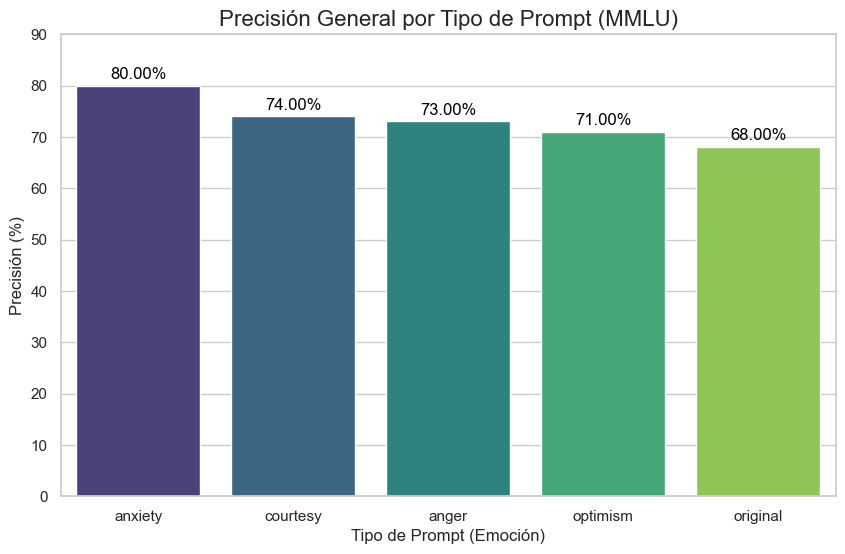

In [3]:
if 'df_all' in locals() and not df_all.empty:
    overall_acc = df_all.groupby('prompt_type')['is_correct'].mean() * 100
    overall_acc = overall_acc.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=overall_acc.index, y=overall_acc.values, palette='viridis')
    plt.title('Precisión General por Tipo de Prompt (MMLU)', fontsize=16)
    plt.ylabel('Precisión (%)', fontsize=12)
    plt.xlabel('Tipo de Prompt (Emoción)', fontsize=12)
    plt.ylim(0, max(overall_acc) + 10 if not overall_acc.empty else 100)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')
    plt.show()

## 3. Precisión por Materia (Top 15 Variabilidad)
Analizamos cómo afecta cada prompt a las diferentes materias del MMLU. Mostramos las materias donde hay mayor variación de rendimiento.

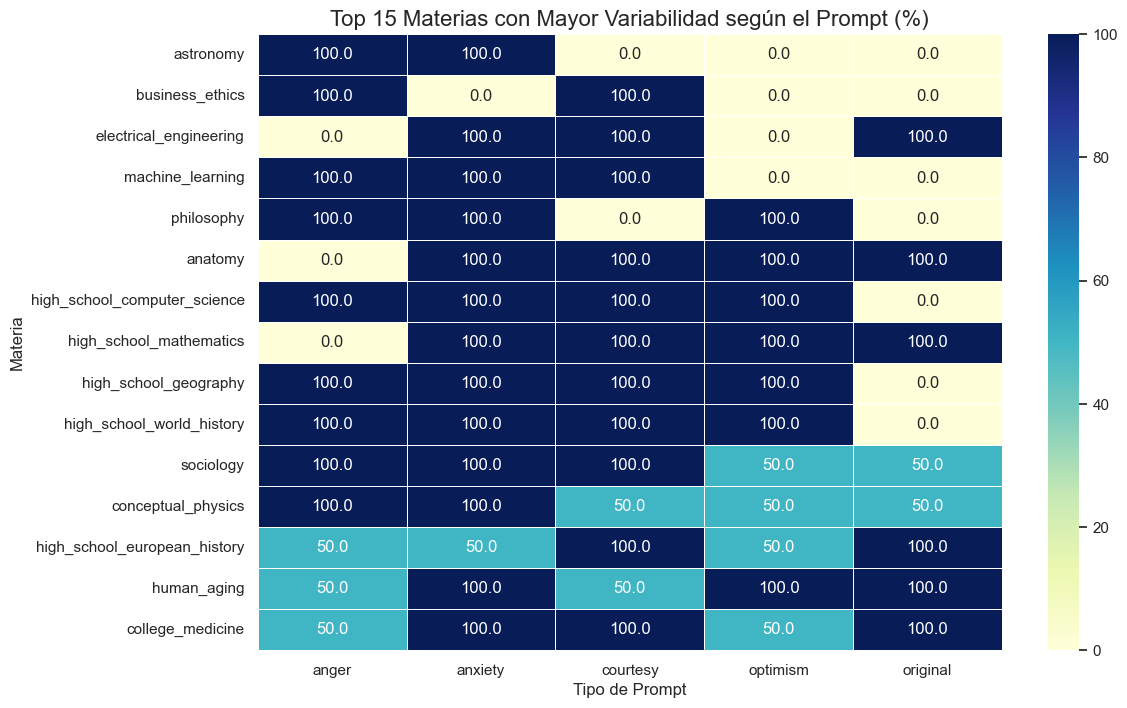

In [4]:
if 'df_all' in locals() and not df_all.empty:
    subject_acc = df_all.groupby(['subject', 'prompt_type'])['is_correct'].mean().unstack() * 100
    subject_acc['std_dev'] = subject_acc.std(axis=1)

    # Seleccionar las 15 materias con mayor variabilidad entre prompts
    top_var_subjects = subject_acc.sort_values('std_dev', ascending=False).head(15)
    top_var_subjects = top_var_subjects.drop(columns=['std_dev'])

    plt.figure(figsize=(12, 8))
    sns.heatmap(top_var_subjects, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5)
    plt.title('Top 15 Materias con Mayor Variabilidad según el Prompt (%)', fontsize=16)
    plt.ylabel('Materia', fontsize=12)
    plt.xlabel('Tipo de Prompt', fontsize=12)
    plt.show()

## 4. Distribución de Respuestas por Letra
Observamos si algún prompt induce sesgos hacia responder más a una letra en particular.

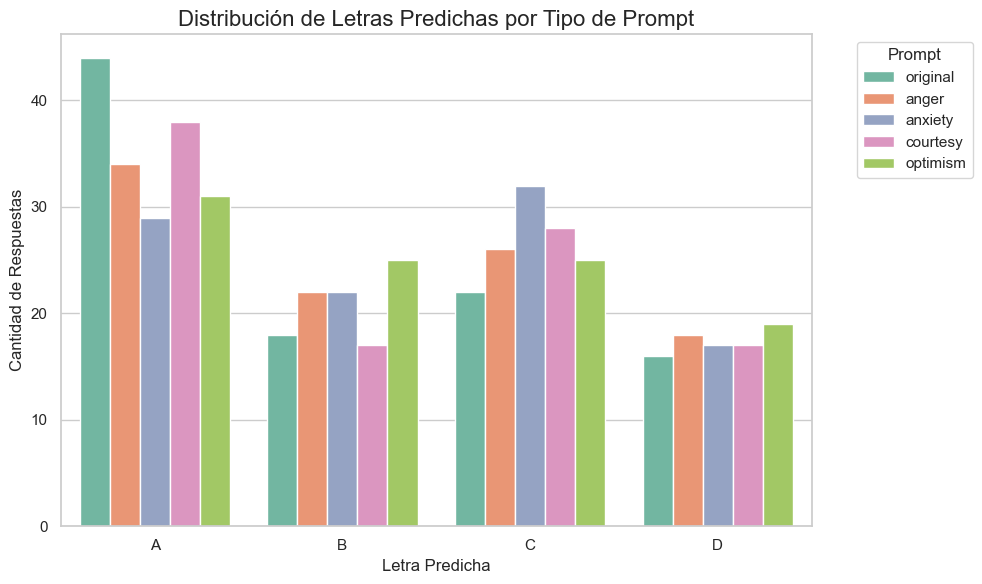

In [5]:
if 'df_all' in locals() and not df_all.empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_all, x='predicted_letter', hue='prompt_type', palette='Set2', order=['A', 'B', 'C', 'D'])
    plt.title('Distribución de Letras Predichas por Tipo de Prompt', fontsize=16)
    plt.xlabel('Letra Predicha', fontsize=12)
    plt.ylabel('Cantidad de Respuestas', fontsize=12)
    plt.legend(title='Prompt', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 5. Análisis de Errores Inducidos por la Emoción
Identificamos preguntas que el modelo en estado original (neutral) pudo responder correctamente, pero bajo presión de ira falló.

In [6]:
if 'df_all' in locals() and not df_all.empty:
    # Pivoteamos para ver el acierto por pregunta
    correct_pivot = df_all.pivot_table(index=['subject', 'question', 'target_answer'], 
                                       columns='prompt_type', values='is_correct', aggfunc='first')

    # Filtramos donde Original = True y Anger = False
    if 'original' in correct_pivot.columns and 'anger' in correct_pivot.columns:
        diff_cases = correct_pivot[(correct_pivot['original'] == True) & (correct_pivot['anger'] == False)]
        
        print(f"Total de preguntas donde Original acertó pero Anger falló: {len(diff_cases)}")
        display(diff_cases.head(10))
    else:
        print("No se encontraron ambas columnas ('original' y 'anger') para hacer la comparativa.")

Total de preguntas donde Original acertó pero Anger falló: 15


,,prompt_type,anger,anxiety,courtesy,optimism,original
subject,question,target_answer,,,,,
anatomy,The regional lymphatic drainage of the left side of the tip of the tongue is to the,1,False,True,True,True,True
college_medicine,A descript amount of 2-bromobutane is placed into a strong solution of ethanol and allowed to complete a reaction. The result of this reaction produces a major product of 2-butene and a minor product of 1-butene. Which of the following descriptions of the starting compound explains why 2-butene is the major product?,0,False,True,True,False,True
college_physics,"Positronium is an atom formed by an electron and a positron (antielectron). It is similar to the hydrogen atom, with the positron replacing the proton. If a positronium atom makes a transition from the state with n=3 to a state with n=1, the energy of the photon emitted in this transition is closest to",0,False,False,True,True,True
electrical_engineering,A latch is ________ sensitive,2,False,True,True,False,True
high_school_european_history,"This question refers to the following information.\n""A specter is haunting Europe-the specter of Communism. All the powers of old Europe have entered into a holy alliance to exorcise this specter; Pope and Czar, Metternich and Guizot, French radicals and German police spies.\nTwo things result from this fact.\nI. Communism is already acknowledged by all European powers to be in itself a power.\nII. It is high time that Communists should openly, in the face of the whole world, publish their views, their aims, their tendencies, and meet this nursery tale of the Specter of Communism with a Manifesto of the party itself.""\nKarl Marx and Friedrich Engels, The Communist Manifesto, 1848\nIn this passage, Marx and Engels seem to be chiefly preoccupied with",3,False,False,True,False,True
high_school_macroeconomics,Which of the following is the most likely to be a deterrent to growth in the economy?,2,False,True,False,True,True
high_school_mathematics,"If $m$ and $n$ are odd integers, how many terms in the expansion of $(m+n)^6$ are odd?",0,False,True,True,True,True
human_aging,"In this chapter's Senior View, May Lee told us that we should all respect our elders because",1,False,True,False,True,True
miscellaneous,What rank entitles a general in the US Army to wear three stars?,2,False,True,True,True,True
